In [73]:
import pandas as pd

path = "../../data/raw/kathmandu_full_raw_2023_2024.csv"

data = pd.read_csv(path)

In [74]:
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time")

Lets create some features based on the time.

In [75]:
data["hour"] = data["time"].dt.hour
data["day_of_week"] = data["time"].dt.dayofweek
data["month"] = data["time"].dt.month

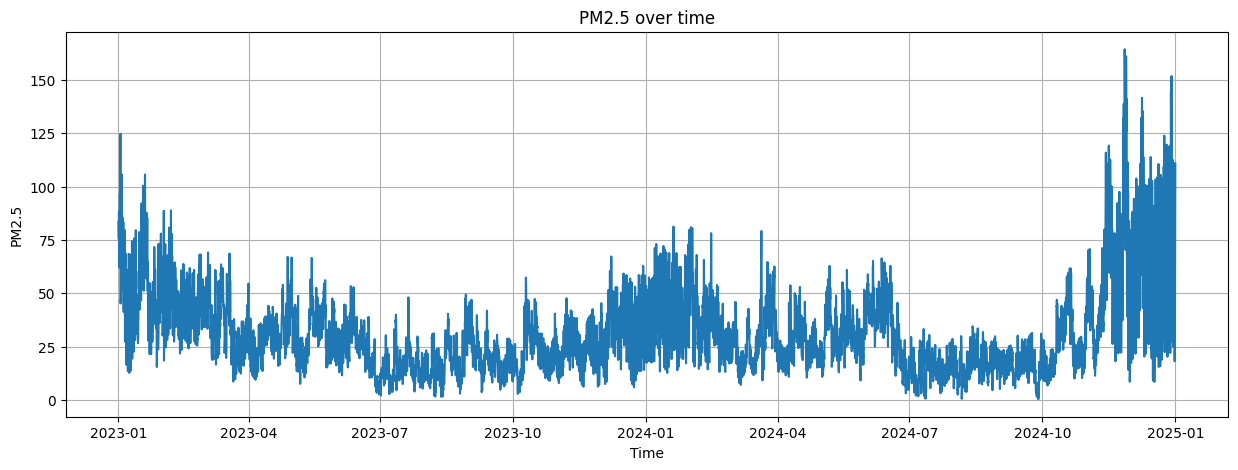

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(data["time"], data["pm2_5"])
plt.title("PM2.5 over time")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()

Lets do monthly analysis

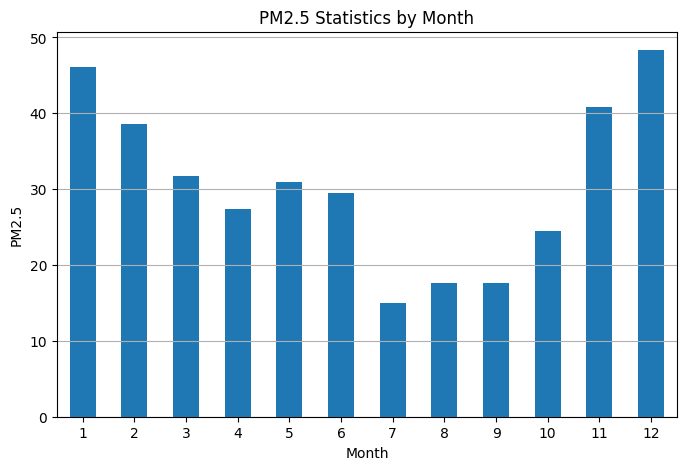

In [77]:
stats = data.groupby("month")["pm2_5"].mean()

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

We can see that data around similar season have similar pattern.  
We will create new feature based on the month and analyze for seasonal pattern. 

In [78]:
def get_season(month):
    if month in [11, 12, 1, 2]:
        return "November_to_February"
    elif month in [3, 4, 5, 6]:
        return "March_to_June"
    elif month in [7, 8, 9, 10]:
        return "July_to_October"

data["season"] = data["time"].dt.month.apply(get_season)

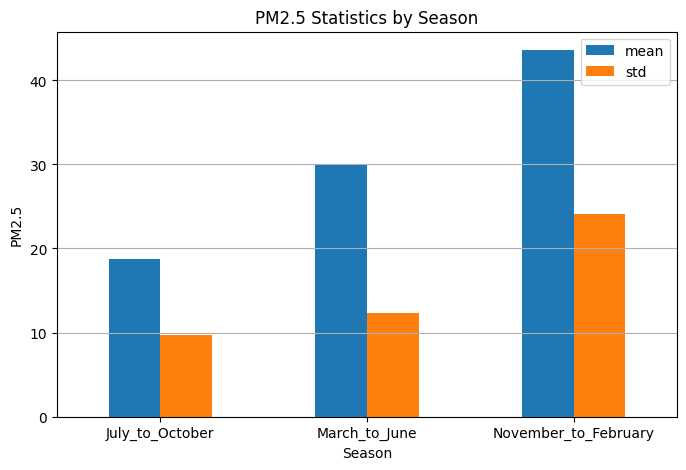

In [79]:
stats = data.groupby("season")["pm2_5"].agg(["mean", "std"]).sort_values(by="mean")

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Season")
plt.xlabel("Season")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

The data also probably depends upon hour of the day.  
Lets analyze.

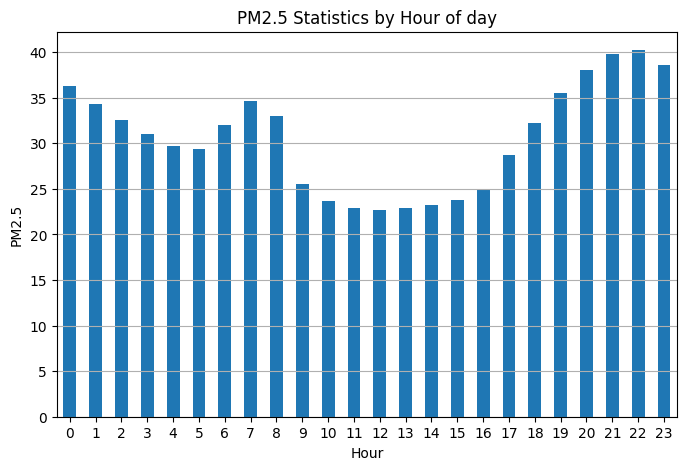

In [80]:
stats = data.groupby("hour")["pm2_5"].mean()

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Hour of day")
plt.xlabel("Hour")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

Lets create a feature for time of day and analyze.

In [81]:
def get_time_of_day(hour):
    if hour in [19, 20, 21, 22, 23, 0]:
        return "7pm_to_12am"
    elif hour in [1, 2, 3, 4, 5, 6, 7, 8]:
        return "1am_to_8am"
    elif hour in [9, 10, 11, 12, 13, 14, 15, 16]:
        return "9am_to_4pm"
    else:
        return "5pm_to_6pm"

data["time_of_day"] = data["hour"].apply(get_time_of_day)

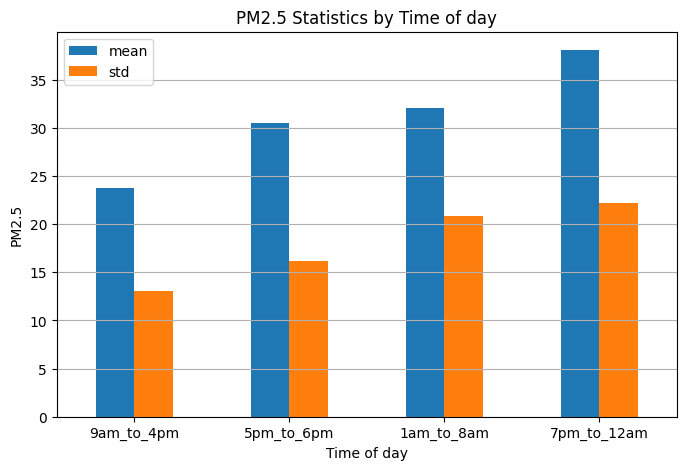

In [82]:
stats = data.groupby("time_of_day")["pm2_5"].agg(["mean", "std"]).sort_values(by="mean")

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Time of day")
plt.xlabel("Time of day")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

The data also probably depends upon day of week.  
Lets analyze.

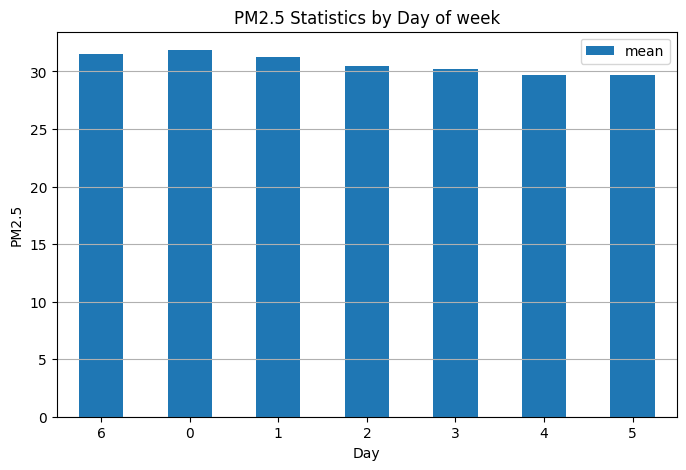

In [83]:
stats = data.groupby("day_of_week")["pm2_5"].agg(["mean"]).reindex([6, 0, 1, 2, 3, 4, 5])

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Day of week")
plt.xlabel("Day")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()